# Experiment №10
## Asymmetric two-tower model that is close to a production training design.

This notebook presents a reproducible two-tower setup for studying embedding dynamics.

- Left tower: Transformer encoder over a user's interaction history (BERT4Rec-style).
- Right tower: Item embedding layer (nn.Embedding).
- Cosine-based loss is used: InfoNCE

I measure orthogonality of updates per each epoch. Then I report popularity bias for item embeddings (correlation with item frequency).

Current experiment represents real-world conditions: moderate size of interactions dataset, production model asymmetric architecture (different optimizers, deep BERT architecture, calculate InfoNCE loss per rows and per columns).

## 1) Setup and configuration

- Dataclasses for model and training configs.
- You can change `cfg` and `train_cfg` to explore variants (e.g., embedding size – bert_hidden_units).



In [1]:
from __future__ import annotations

# Core imports
import math
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple, Sequence

import numpy as np
import pandas as pd
from tqdm import tqdm
import plotly.express as px
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from info_nce import InfoNCE

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device: str = 'cuda' if torch.cuda.is_available() else 'cpu'

# Configuration
@dataclass
class ModelConfig:
    bert_max_len: int = 50
    bert_hidden_units: int = 100
    bert_num_blocks: int = 2
    bert_num_heads: int = 2
    bert_dropout: float = 0.1
    bert_mask_prob: float = 0.15
    num_items: int = 0  # set after dataset init

@dataclass
class TrainConfig:
    # general params:
    data_fraction: float = 1.0 # use first X fraction of ratings rows
    epochs: int = 100
    batch_size: int = 256
    # user tower params:
    lr_user: float = 1e-3      # Adam learning rate for user encoder
    user_bert_tower_regularization: float = 1e-2  # weight decay for Adam (user tower)
    # item tower params:
    lr_item: float = 10.0      # SGD learning rate for item embeddings

cfg = ModelConfig()
train_cfg = TrainConfig()

## 2) Data (MovieLens 32M) — brief EDA

Permalink: https://grouplens.org/datasets/movielens/32m/

I load ratings and movies, then report: number of users, items, interactions per user. Sequences are built by sorting user interactions by timestamp.


In [2]:
# Load MovieLens 32M and build sequences (ultra-brief EDA)
DATA_DIR = "../ml-32m"
ratings = pd.read_csv(f"{DATA_DIR}/ratings.csv")  # userId,movieId,rating,timestamp
# take only first fraction of rows for faster experiments
if train_cfg.data_fraction < 1:
    ratings = ratings[:int(len(ratings) * train_cfg.data_fraction)]

# EDA
num_users = ratings.userId.nunique()
num_items = ratings.movieId.nunique()
print("Users:", num_users, ", items:", num_items)

# Build sequences: sort by timestamp per user
ratings_sorted = ratings.sort_values(["userId", "timestamp"])  # ascending time

# Map ids to contiguous indices
u2ix = {u: i for i, u in enumerate(ratings_sorted.userId.unique())}
i2ix = {i: j for j, i in enumerate(ratings_sorted.movieId.unique())}
ix2i = {j: i for i, j in i2ix.items()}

encoded = ratings_sorted.copy()
encoded["user_id"] = encoded.userId.map(u2ix)
encoded["item_id"] = encoded.movieId.map(i2ix)

# sequences of item indices per numeric user id
train_sequences = (
    encoded.groupby('user_id', group_keys=False)[['item_id']]
    .apply(lambda d: list(d['item_id']))
    .to_dict()
)

mean_len_train_sequences = np.mean([len(v) for v in train_sequences.values()])
median_len_train_sequences = np.median([len(v) for v in train_sequences.values()])
print("Mean user interactions length:", mean_len_train_sequences, ", median user interactions length:", median_len_train_sequences)

cfg.num_items = len(i2ix)


Users: 200948 , items: 84432
Mean user interactions length: 159.24619304496684 , median user interactions length: 73.0


## 3) Dataloader (BERT4Rec-style masking)

I implement the standard BERT4Rec masking ([jaywonchung's BERT4Rec implementation](https://github.com/jaywonchung/BERT4Rec-VAE-Pytorch/)): replace with [MASK] token (80%), random token (10%), or keep original (10%); labels are the original token for masked positions and 0 (PAD) otherwise.


In [3]:
class BertTrainDataset(torch.utils.data.Dataset):
    """BERT-style masking over user item sequences.

    Returns a pair (tokens, labels):
    - tokens: sequence of item ids with dynamic masking applied
      (0 is PAD, `mask_token` denotes [MASK]).
    - labels: original item ids at masked positions, 0 elsewhere.
    """
    def __init__(self, user2seq, max_len, mask_prob, mask_token, num_items, rng):
        self.u2seq = user2seq
        self.users = sorted(self.u2seq.keys())
        self.max_len = max_len
        self.mask_prob = mask_prob
        self.mask_token = mask_token
        self.num_items = num_items
        self.rng = rng

    def __len__(self):
        return len(self.users)

    def __getitem__(self, index):
        user = self.users[index]
        seq = self.u2seq[user]

        tokens = []
        labels = []
        for s in seq:
            prob = self.rng.random()
            if prob < self.mask_prob:
                prob /= self.mask_prob
                # 80% => [MASK], 10% => random token, 10% => keep original
                if prob < 0.8:
                    tokens.append(self.mask_token)
                elif prob < 0.9:
                    tokens.append(self.rng.randint(1, self.num_items))
                else:
                    tokens.append(s)
                labels.append(s)
            else:
                tokens.append(s)
                labels.append(0)

        # left-pad to fixed length
        tokens = tokens[-self.max_len:]
        labels = labels[-self.max_len:]
        pad_len = self.max_len - len(tokens)
        tokens = [0] * pad_len + tokens
        labels = [0] * pad_len + labels

        return torch.LongTensor(tokens), torch.LongTensor(labels)

# Hyperparameters (use cfg from ModelConfig)
# cfg.num_items was set after dataset init
train_dataset = BertTrainDataset(
    user2seq=train_sequences,
    max_len=cfg.bert_max_len,
    mask_prob=cfg.bert_mask_prob,
    mask_token=cfg.num_items + 1,
    num_items=cfg.num_items,
    rng=random.Random(42)
)

train_loader = DataLoader(train_dataset, batch_size=train_cfg.batch_size, shuffle=True)


In [4]:
print(f'Batch example for user interaction sequences (here "item_id == {cfg.num_items + 1}" is masked token): \n')
next(iter(train_loader))

Batch example for user interaction sequences (here "item_id == 84433" is masked token): 



[tensor([[    0,     0,     0,  ...,  4418, 84433, 84433],
         [    0,     0,     0,  ..., 84433,   533,   361],
         [39322,  4312,   700,  ..., 84433,   269,   167],
         ...,
         [ 2147,  5559,   626,  ...,  3053, 10429,  3963],
         [ 3644,  1307, 22797,  ...,   519, 84433,  4105],
         [ 2403,  1469,  1313,  ...,  3038,  2385,  1614]]),
 tensor([[   0,    0,    0,  ...,    0, 1423, 9502],
         [   0,    0,    0,  ...,  506,    0,    0],
         [ 957,    0,    0,  ...,  136,    0,    0],
         ...,
         [   0,    0,    0,  ...,    0,    0,    0],
         [   0,    0,    0,  ...,    0, 3103,    0],
         [   0,    0,    0,  ...,    0,    0,    0]])]

## 4) Model (Two-Tower)

Left tower is a Transformer over tokenized user history; right tower is an item embedding table. I preserve the architecture from [jaywonchung's BERT4Rec implementation](https://github.com/jaywonchung/BERT4Rec-VAE-Pytorch/), adding only docstrings and minor formatting for clarity.


In [5]:
class TokenEmbedding(nn.Embedding):
    def __init__(self, vocab_size, embed_size):
        super().__init__(vocab_size, embed_size, padding_idx=0)

class PositionalEmbedding(nn.Module):
    def __init__(self, max_len, d_model):
        super().__init__()
        self.pe = nn.Embedding(max_len, d_model)

    def forward(self, x):
        return self.pe.weight.unsqueeze(0).repeat(x.size(0), 1, 1)

class BERTEmbedding(nn.Module):
    """Token + positional embeddings with dropout (BERT-style)."""
    def __init__(self, vocab_size, embed_size, max_len, dropout=0.1):
        super().__init__()
        self.token = TokenEmbedding(vocab_size, embed_size)
        self.position = PositionalEmbedding(max_len, embed_size)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, sequence):
        x = self.token(sequence) + self.position(sequence)
        return self.dropout(x)

class LayerNorm(nn.Module):
    def __init__(self, features, eps=1e-6):
        super().__init__()
        self.a_2 = nn.Parameter(torch.ones(features))
        self.b_2 = nn.Parameter(torch.zeros(features))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        std = x.std(-1, keepdim=True)
        return self.a_2 * (x - mean) / (std + self.eps) + self.b_2

class Attention(nn.Module):
    def forward(self, query, key, value, mask=None, dropout=None):
        scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(query.size(-1))
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        p_attn = F.softmax(scores, dim=-1)
        if dropout is not None:
            p_attn = dropout(p_attn)
        return torch.matmul(p_attn, value), p_attn

class MultiHeadedAttention(nn.Module):
    def __init__(self, h, d_model, dropout=0.1):
        super().__init__()
        assert d_model % h == 0
        self.d_k = d_model // h
        self.h = h
        self.linear_layers = nn.ModuleList([nn.Linear(d_model, d_model) for _ in range(3)])
        self.output_linear = nn.Linear(d_model, d_model)
        self.attention = Attention()
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)
        query, key, value = [l(x).view(batch_size, -1, self.h, self.d_k).transpose(1, 2)
                             for l, x in zip(self.linear_layers, (query, key, value))]
        x, attn = self.attention(query, key, value, mask=mask, dropout=self.dropout)
        x = x.transpose(1, 2).contiguous().view(batch_size, -1, self.h * self.d_k)
        return self.output_linear(x)

class GELU(nn.Module):
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))

class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.activation = GELU()

    def forward(self, x):
        return self.w_2(self.dropout(self.activation(self.w_1(x))))

class TransformerBlock(nn.Module):
    def __init__(self, hidden, attn_heads, feed_forward_hidden, dropout):
        super().__init__()
        self.layernorm1 = LayerNorm(hidden)
        self.multiheadedattention = MultiHeadedAttention(h=attn_heads, d_model=hidden, dropout=dropout)
        self.dropout1 = nn.Dropout(dropout)
        self.layernorm2 = LayerNorm(hidden)
        self.feed_forward = PositionwiseFeedForward(d_model=hidden, d_ff=feed_forward_hidden, dropout=dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, mask):
        x_skip_connection1 = x
        x = self.layernorm1(x)
        x = self.multiheadedattention(x, x, x, mask)
        x = self.dropout1(x)
        x += x_skip_connection1
        x_skip_connection2 = x
        x = self.layernorm2(x)
        x = self.feed_forward(x)
        x = self.dropout2(x)
        x += x_skip_connection2
        return self.dropout3(x)

class BERTUserEncoder(nn.Module):
    def __init__(self, cfg: ModelConfig):
        super().__init__()
        vocab_size = cfg.num_items + 2
        hidden = cfg.bert_hidden_units
        max_len = cfg.bert_max_len
        n_layers = cfg.bert_num_blocks
        heads = cfg.bert_num_heads
        dropout = cfg.bert_dropout
        self.embedding = BERTEmbedding(vocab_size=vocab_size, embed_size=hidden, max_len=max_len, dropout=dropout)
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(hidden, heads, hidden * 4, dropout) for _ in range(n_layers)
        ])
        self.final_linear = nn.Linear(cfg.bert_hidden_units, cfg.bert_hidden_units, bias=False)

    def forward(self, x):
        mask = (x > 0).unsqueeze(1).repeat(1, x.size(1), 1).unsqueeze(1)
        x = self.embedding(x)
        for transformer in self.transformer_blocks:
            x = transformer(x, mask)
        x = self.final_linear(x)
        return x

class TwoTowerModel(nn.Module):
    def __init__(self, cfg: ModelConfig):
        super().__init__()
        self.user_encoder = BERTUserEncoder(cfg).double()
        self.item_embedding = nn.Embedding(cfg.num_items + 1, cfg.bert_hidden_units).double()

    def get_user_embeddings(self, user_tokens):
        return self.user_encoder(user_tokens)

    def get_item_embeddings(self, item_ids):
        return self.item_embedding(item_ids)

    def forward(self, user_tokens, item_ids):
        return self.get_user_embeddings(user_tokens), self.get_item_embeddings(item_ids)



## 5) Training and visualization

In [6]:
def report_embedding_shift_orthogonality(
    old_users_embeddings,
    old_items_embeddings,
    new_users_embeddings,
    new_items_embeddings,
):
    old_users_embeddings = old_users_embeddings.detach().cpu().numpy()
    old_items_embeddings = old_items_embeddings.detach().cpu().numpy()
    new_users_embeddings = new_users_embeddings.detach().cpu().numpy()
    new_items_embeddings = new_items_embeddings.detach().cpu().numpy()

    def which_share_of_objects_moved_orthogonally(old, new):
        cnt = 0
        for i in range(len(old)):
            position_delta = new[i] - old[i]
            if math.isclose(float(position_delta @ old[i]), 0.0, abs_tol=1e-7):
                cnt += 1
        return cnt / len(old)

    frac_users = which_share_of_objects_moved_orthogonally(old_users_embeddings, new_users_embeddings)
    frac_items = which_share_of_objects_moved_orthogonally(old_items_embeddings, new_items_embeddings)

    print(f"Fraction of strictly orthogonal shifts (users): {frac_users:.6f}")
    print(f"Fraction of strictly orthogonal shifts (items): {frac_items:.6f}")

In [7]:
# --- Recommendation evaluation setup (top-1% in top-100) ---
# Popularity from training data
popularity_train = encoded.groupby('item_id').size()
pop_arr_train = popularity_train.reindex(range(cfg.num_items), fill_value=0).to_numpy()

top_1pct_k = max(1, int(math.ceil(0.01 * cfg.num_items)))
top_k_reco = min(100, cfg.num_items)
top_pop_idx = np.argpartition(pop_arr_train, -top_1pct_k)[-top_1pct_k:]

top_pop_mask = torch.zeros(cfg.num_items, dtype=torch.bool)
top_pop_mask[top_pop_idx] = True

def build_eval_tokens(user2seq, max_len, mask_token):
    user_ids = sorted(user2seq.keys())
    tokens = np.zeros((len(user_ids), max_len), dtype=np.int64)
    mask_positions = np.zeros(len(user_ids), dtype=np.int64)

    for i, u in enumerate(user_ids):
        seq = user2seq[u]
        if len(seq) == 0:
            mask_positions[i] = max_len - 1
            continue
        seq = seq[-max_len:].copy()
        seq[-1] = mask_token
        pad_len = max_len - len(seq)
        tokens[i, pad_len:] = np.asarray(seq, dtype=np.int64)
        mask_positions[i] = pad_len + len(seq) - 1

    return torch.from_numpy(tokens), torch.from_numpy(mask_positions), user_ids

eval_user_tokens, eval_mask_positions, eval_user_ids = build_eval_tokens(
    user2seq=train_sequences,
    max_len=cfg.bert_max_len,
    mask_token=cfg.num_items + 1,
)

def compute_top1pct_share_by_user(
    model,
    user_tokens,
    mask_positions,
    top_pop_mask,
    top_k,
    batch_size,
    device,
):
    was_training = model.training
    model.eval()
    shares_cos = []
    shares_dot = []

    with torch.no_grad():
        item_ids = torch.arange(cfg.num_items, dtype=torch.long, device=device)
        item_embs = model.get_item_embeddings(item_ids).float()
        item_embs_norm = F.normalize(item_embs, dim=1)
        top_pop_mask = top_pop_mask.to(device)

        for start in range(0, user_tokens.size(0), batch_size):
            end = start + batch_size
            batch_tokens = user_tokens[start:end].to(device)
            batch_pos = mask_positions[start:end].to(device)

            user_embs = model.get_user_embeddings(batch_tokens)
            row_idx = torch.arange(batch_tokens.size(0), device=device)
            user_vecs = user_embs[row_idx, batch_pos].float()

            # dot product
            scores_dot = user_vecs @ item_embs.t()
            top_dot = torch.topk(scores_dot, k=top_k, dim=1).indices
            share_dot = top_pop_mask[top_dot].float().mean(dim=1)
            shares_dot.append(share_dot.cpu())

            # cosine similarity
            user_norm = F.normalize(user_vecs, dim=1)
            scores_cos = user_norm @ item_embs_norm.t()
            top_cos = torch.topk(scores_cos, k=top_k, dim=1).indices
            share_cos = top_pop_mask[top_cos].float().mean(dim=1)
            shares_cos.append(share_cos.cpu())

    if was_training:
        model.train()

    return torch.cat(shares_cos).numpy(), torch.cat(shares_dot).numpy()

In [8]:
model = TwoTowerModel(cfg).to(device)

# Mixed optimizers: Adam for user tower, SGD for item tower
optimizer_user = torch.optim.Adam(
    model.user_encoder.parameters(),
    lr=train_cfg.lr_user,
    weight_decay=train_cfg.user_bert_tower_regularization
)
optimizer_item = torch.optim.SGD(model.item_embedding.parameters(), lr=train_cfg.lr_item, momentum=0)

steps_per_epoch = len([x for x in train_loader])

base_lr_user = train_cfg.lr_user
max_lr_user  = train_cfg.lr_user * 10
scheduler_user = torch.optim.lr_scheduler.CyclicLR(
    optimizer_user,
    base_lr=base_lr_user,
    max_lr=max_lr_user,
    step_size_up=max(1, steps_per_epoch // 2),
    step_size_down=steps_per_epoch - max(1, steps_per_epoch // 2),
    mode="triangular",
    cycle_momentum=False
)

base_lr_item = train_cfg.lr_item
max_lr_item  = train_cfg.lr_item * 10
scheduler_item = torch.optim.lr_scheduler.CyclicLR(
    optimizer_item,
    base_lr=base_lr_item,
    max_lr=max_lr_item,
    step_size_up=max(1, steps_per_epoch // 2),
    step_size_down=steps_per_epoch - max(1, steps_per_epoch // 2),
    mode="triangular",
    cycle_momentum=False
)

infonceloss = InfoNCE(temperature=0.1)
loss_history: List[float] = []

eval_every = 10
rec_batch_size = 256
pop_share_by_epoch = {}
pop_share_summary = []

model.train()
for epoch in range(train_cfg.epochs):
    embeds_already_visualized_this_epoch = False
    
    for batch_tokens, batch_labels in tqdm(train_loader, desc=f'Epoch {epoch}'):
        batch_tokens = batch_tokens.to(device)
        batch_labels = batch_labels.to(device)

        # mask valid training positions (non-PAD labels)
        mask = batch_labels != 0
        if not mask.any():
            continue

        user_embs, item_embs = model(batch_tokens, batch_labels)

        user_vecs = user_embs[mask]
        pos_item_vecs = item_embs[mask]

        # calculate loss per rows(which items this user interacted with) and per columns (which users interacted with this item)
        loss = infonceloss(user_vecs, pos_item_vecs) + infonceloss(pos_item_vecs, user_vecs)

        optimizer_user.zero_grad()
        optimizer_item.zero_grad()
        loss.backward()

        # cache pre-step embeddings for orthogonality
        old_users_embeddings = user_vecs.detach().clone()
        old_items_embeddings = pos_item_vecs.detach().clone()

        optimizer_user.step()
        optimizer_item.step()
        scheduler_user.step()
        scheduler_item.step()

        # new embeddings after step
        with torch.no_grad():
            user_embs_new, item_embs_new = model(batch_tokens, batch_labels)
            user_vecs_new = user_embs_new[mask]
            pos_item_vecs_new = item_embs_new[mask]

        if len(batch_tokens) == train_cfg.batch_size:
            loss_history.append(float(loss.item()))

        if not embeds_already_visualized_this_epoch:
            report_embedding_shift_orthogonality(
                old_users_embeddings,
                old_items_embeddings,
                user_vecs_new,
                pos_item_vecs_new
            )
            embeds_already_visualized_this_epoch = True

    if (epoch < 10) or (epoch % eval_every == (eval_every - 1)):
        cos_share, dot_share = compute_top1pct_share_by_user(
            model=model,
            user_tokens=eval_user_tokens,
            mask_positions=eval_mask_positions,
            top_pop_mask=top_pop_mask,
            top_k=top_k_reco,
            batch_size=rec_batch_size,
            device=device,
        )

        pop_share_by_epoch[epoch] = {"cosine": cos_share, "dot": dot_share}
        pop_share_summary.append({
            "epoch": epoch,
            "cosine_mean": float(np.mean(cos_share)),
            "dot_mean": float(np.mean(dot_share)),
        })
        print(
            f"Epoch {epoch} | top-1% in top-100 mean: "
            f"cosine={pop_share_summary[-1]['cosine_mean']:.4f}, "
            f"dot={pop_share_summary[-1]['dot_mean']:.4f}"
        )

Epoch 0:   1%|          | 6/785 [00:00<00:49, 15.75it/s]

Fraction of strictly orthogonal shifts (users): 0.000000
Fraction of strictly orthogonal shifts (items): 1.000000


Epoch 0: 100%|██████████| 785/785 [00:18<00:00, 42.12it/s]


Epoch 0 | top-1% in top-100 mean: cosine=0.0000, dot=0.0000


Epoch 1:   1%|          | 4/785 [00:00<00:21, 35.84it/s]

...

Fraction of strictly orthogonal shifts (users): 0.000000
Fraction of strictly orthogonal shifts (items): 1.000000


Epoch 99:   1%|          | 9/785 [00:00<00:18, 41.85it/s]

Fraction of strictly orthogonal shifts (users): 0.000000
Fraction of strictly orthogonal shifts (items): 1.000000


Epoch 99: 100%|██████████| 785/785 [00:18<00:00, 42.80it/s]


Epoch 99 | top-1% in top-100 mean: cosine=0.3220, dot=0.6342


/tmp/ipykernel_746/1127327201.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


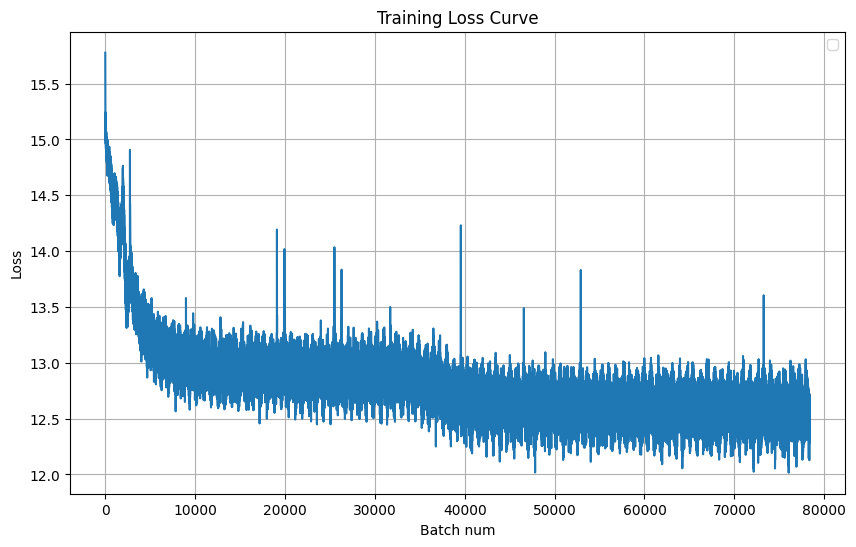

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(loss_history)
plt.xlabel('Batch num')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

## Popularity bias

Correlation between item embedding norms and item popularity (frequency in training):

In [10]:
# Collect final item embeddings and compute popularity correlation
with torch.no_grad():
    # all item ids in index space
    all_item_ids = torch.arange(cfg.num_items, dtype=torch.long, device=device)
    item_emb_matrix = model.get_item_embeddings(all_item_ids)
item_norms = torch.norm(item_emb_matrix, dim=1).cpu().numpy()

# popularity from encoded training data
popularity = encoded.groupby('item_id').size()
# align to full range [0..num_items-1]
pop_arr = popularity.reindex(range(cfg.num_items), fill_value=0).to_numpy()

# Pearson correlation
corr = np.corrcoef(item_norms, pop_arr)[0, 1]
print("Correlation(norm(item), popularity):", float(corr))

Correlation(norm(item), popularity): 0.5696369716503025


## Popularity entanglement (permutation baseline)

I test whether the correlation between item embedding norms and item popularity is above what would be expected by chance.

- Null (H0): the observed correlation arises from random alignment between norms and popularity.
- Test: compute empirical correlation r_emp; then permute popularity counts K times to build a null distribution of r_perm. Report p-value and z-score.

Interpretation:
- Low p-value (e.g., < 0.01) and high z-score → popularity entanglement is significant (bad: embeddings encode popularity magnitude).
- High p-value → correlation could be random (less concerning).

In [11]:
# ensure we have final item embeddings and popularity vector
with torch.no_grad():
    all_item_ids = torch.arange(cfg.num_items, dtype=torch.long, device=device)
    item_emb_matrix = model.get_item_embeddings(all_item_ids)
item_norms = torch.norm(item_emb_matrix, dim=1).cpu().numpy()

popularity = encoded.groupby('item_id').size()
pop_arr = popularity.reindex(range(cfg.num_items), fill_value=0).to_numpy()

# empirical correlation
r_emp = np.corrcoef(item_norms, pop_arr)[0, 1]

# permutation test
K = 200
r_perm = np.empty(K, dtype=float)
for k in range(K):
    perm = np.random.permutation(pop_arr)
    r_perm[k] = np.corrcoef(item_norms, perm)[0, 1]

mu = float(r_perm.mean())
sigma = float(r_perm.std(ddof=1) + 1e-12)
z = (r_emp - mu) / sigma
# two-sided p-value under normal approx
from math import erf, sqrt
p_value = 2 * (1 - 0.5 * (1 + erf(abs(z) / sqrt(2))))

print(f"Empirical corr r_emp = {r_emp:.4f}")
print(f"Permutation null: mean={mu:.4f}, std={sigma:.4f}, z={z:.2f}, p-value={p_value:.3g}")

# brief interpretation
if p_value < 0.01 and r_emp > 0:
    print("Verdict: Significant popularity entanglement (bad: norms encode popularity magnitude).")
elif p_value < 0.05 and r_emp > 0:
    print("Verdict: Likely entanglement (watch out for bias).")
else:
    print("Verdict: No strong evidence beyond chance (less concerning).")

Empirical corr r_emp = 0.5696
Permutation null: mean=0.0002, std=0.0035, z=163.65, p-value=0
Verdict: Significant popularity entanglement (bad: norms encode popularity magnitude).


## Top-1% popular share in top-100 recommendations

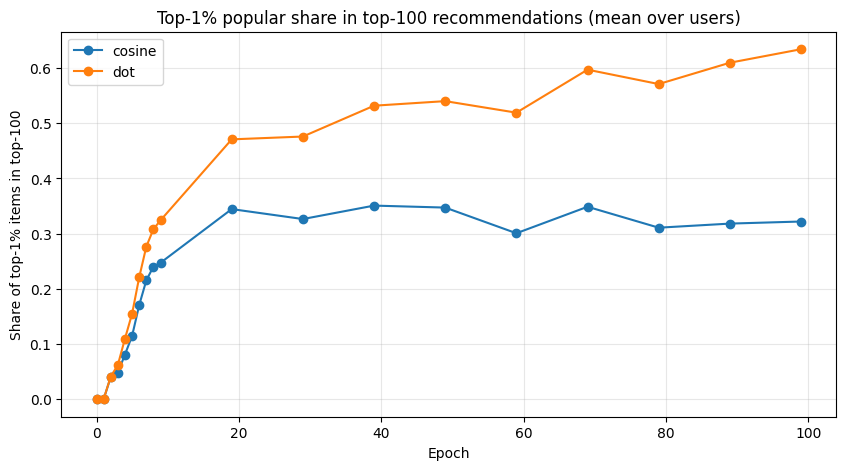

/tmp/ipykernel_746/345048940.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
/tmp/ipykernel_746/345048940.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


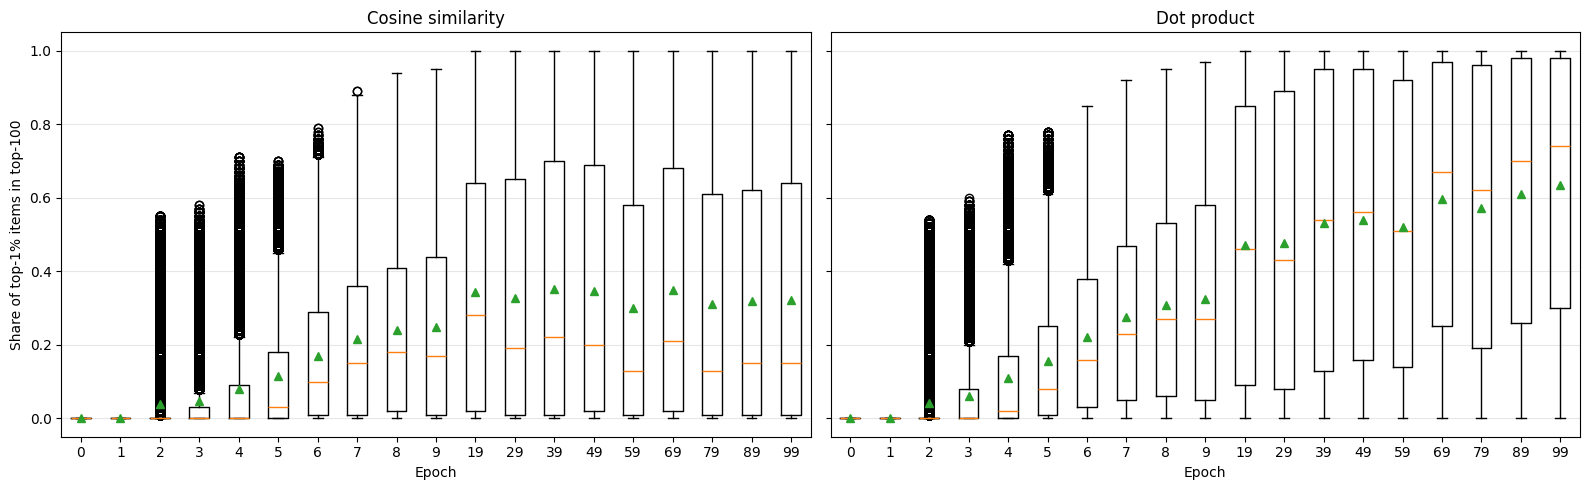

In [12]:
epochs = sorted(pop_share_by_epoch.keys())

cos_mean = [float(pop_share_by_epoch[e]["cosine"].mean()) for e in epochs]
dot_mean = [float(pop_share_by_epoch[e]["dot"].mean()) for e in epochs]

plt.figure(figsize=(10, 5))
plt.plot(epochs, cos_mean, marker="o", label="cosine")
plt.plot(epochs, dot_mean, marker="o", label="dot")
plt.xlabel("Epoch")
plt.ylabel("Share of top-1% items in top-100")
plt.title("Top-1% popular share in top-100 recommendations (mean over users)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

axes[0].boxplot(
    [pop_share_by_epoch[e]["cosine"] for e in epochs],
    labels=[str(e) for e in epochs],
    showmeans=True
)
axes[0].set_title("Cosine similarity")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Share of top-1% items in top-100")
axes[0].grid(axis="y", alpha=0.3)

axes[1].boxplot(
    [pop_share_by_epoch[e]["dot"] for e in epochs],
    labels=[str(e) for e in epochs],
    showmeans=True
)
axes[1].set_title("Dot product")
axes[1].set_xlabel("Epoch")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

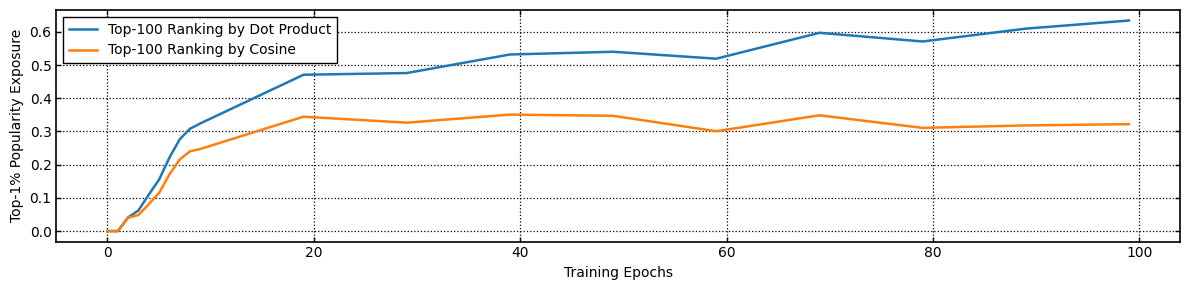

In [13]:
epochs = sorted(pop_share_by_epoch.keys())
cos_mean = [float(pop_share_by_epoch[e]["cosine"].mean()) for e in epochs]
dot_mean = [float(pop_share_by_epoch[e]["dot"].mean()) for e in epochs]

fig, ax = plt.subplots(figsize=(12, 3))

ax.plot(epochs, dot_mean, linewidth=1.8, label="Top-100 Ranking by Dot Product")
ax.plot(epochs, cos_mean, linewidth=1.8, label="Top-100 Ranking by Cosine")

ax.set_xlabel("Training Epochs")
ax.set_ylabel("Top-1% Popularity Exposure")

for s in ax.spines.values():
    s.set_color("black")
    s.set_linewidth(1.2)

ax.tick_params(direction="in", top=True, right=True, colors="black", width=1.0)

ax.grid(True, which="major", linestyle=":", linewidth=0.9, color="black")

leg = ax.legend(frameon=True, fancybox=False, framealpha=1.0, edgecolor="black")
leg.get_frame().set_linewidth(1.0)

plt.tight_layout()
fig.savefig("figure_3_paper.pdf", bbox_inches="tight", dpi=300)
plt.show()